In [74]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io as sio

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [75]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

LR_HEAD = 3e-4
LR_FINE = 5e-5
WEIGHT_DECAY = 1e-3
PATIENCE = 3

EPOCHS_HEAD = 2
EPOCHS_FINE = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [76]:
DATA_ROOT = "/kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset"
DEVKIT_ROOT = os.path.join(DATA_ROOT, "car_devkit", "devkit")
TRAIN_IMG_ROOT = os.path.join(DATA_ROOT, "cars_train", "cars_train")
TEST_IMG_ROOT = os.path.join(DATA_ROOT, "cars_test", "cars_test")

print("DATA_ROOT:", DATA_ROOT)
print("DEVKIT_ROOT:", DEVKIT_ROOT)
print("TRAIN_IMG_ROOT:", TRAIN_IMG_ROOT)
print("TEST_IMG_ROOT:", TEST_IMG_ROOT)

DATA_ROOT: /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset
DEVKIT_ROOT: /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/car_devkit/devkit
TRAIN_IMG_ROOT: /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/cars_train/cars_train
TEST_IMG_ROOT: /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/cars_test/cars_test


In [77]:
def to_str(x):
    """Convert MATLAB-loaded strings/arrays to clean Python strings."""
    while isinstance(x, np.ndarray):
        if x.size == 0:
            return ""
        if x.size == 1:
            x = x.item()
        else:
            x = x[0]
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="ignore")
    return str(x).strip()

def get_field(obj, *names, default=None):
    """Try multiple possible field names."""
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)
    if default is not None:
        return default
    raise AttributeError(f"None of these fields exist: {names}")

In [78]:
def load_class_names(devkit_root):
    meta_path = os.path.join(devkit_root, "cars_meta.mat")
    meta = sio.loadmat(meta_path, squeeze_me=True, struct_as_record=False)

    raw = meta["class_names"]
    raw = np.atleast_1d(raw)

    names = []
    for x in raw:
        names.append(to_str(x))
    return names

def load_annotations(devkit_root, split="train"):
    if split == "train":
        ann_file = "cars_train_annos.mat"
    elif split == "test":
        ann_file = "cars_test_annos.mat"
    else:
        raise ValueError("split must be 'train' or 'test'")

    ann_path = os.path.join(devkit_root, ann_file)
    mat = sio.loadmat(ann_path, squeeze_me=True, struct_as_record=False)
    anns = np.atleast_1d(mat["annotations"])

    rows = []
    for ann in anns:
        row = {
            "fname": to_str(get_field(ann, "fname")),
            "bbox_x1": int(get_field(ann, "bbox_x1", "box_x1")),
            "bbox_y1": int(get_field(ann, "bbox_y1", "box_y1")),
            "bbox_x2": int(get_field(ann, "bbox_x2", "box_x2")),
            "bbox_y2": int(get_field(ann, "bbox_y2", "box_y2")),
        }

        # Label may or may not exist in the copy of the test file
        if hasattr(ann, "class"):
            row["label"] = int(getattr(ann, "class")) - 1
        elif hasattr(ann, "label"):
            row["label"] = int(getattr(ann, "label")) - 1

        rows.append(row)

    return pd.DataFrame(rows)

In [79]:
class_names = load_class_names(DEVKIT_ROOT)
train_df = load_annotations(DEVKIT_ROOT, "train")
test_df = load_annotations(DEVKIT_ROOT, "test")

print("Classes:", len(class_names))
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
print(train_df.head())
print(test_df.head())

Classes: 196
Train columns: ['fname', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'label']
Test columns: ['fname', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2']
       fname  bbox_x1  bbox_y1  bbox_x2  bbox_y2  label
0  00001.jpg       39      116      569      375     13
1  00002.jpg       36      116      868      587      2
2  00003.jpg       85      109      601      381     90
3  00004.jpg      621      393     1484     1096    133
4  00005.jpg       14       36      133       99    105
       fname  bbox_x1  bbox_y1  bbox_x2  bbox_y2
0  00001.jpg       30       52      246      147
1  00002.jpg      100       19      576      203
2  00003.jpg       51      105      968      659
3  00004.jpg       67       84      581      407
4  00005.jpg      140      151      593      339


In [80]:
class CarsDataset(Dataset):
    def __init__(self, img_root, df, transform=None, return_label=True):
        self.img_root = img_root
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.return_label = return_label and ("label" in self.df.columns)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_root, row["fname"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.return_label:
            label = int(row["label"])
            return image, label
        else:
            return image

In [81]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["label"]
)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.05),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

train_set = CarsDataset(TRAIN_IMG_ROOT, train_df.iloc[train_idx], transform=train_tfms, return_label=True)
val_set = CarsDataset(TRAIN_IMG_ROOT, train_df.iloc[val_idx], transform=val_tfms, return_label=True)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train size:", len(train_set))
print("Val size:", len(val_set))

Train size: 6922
Val size: 1222


In [82]:
def build_model(num_classes):
    try:
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)
    except Exception:
        model = models.convnext_tiny(weights=None)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(len(class_names)).to(device)
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [83]:
def freeze_backbone_train_head_only(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

def make_optimizer(model, lr):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

In [84]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

/tmp/ipykernel_57/132689120.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [85]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for batch in loader:
        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(
                device_type="cuda" if device.type == "cuda" else "cpu",
                enabled=(device.type == "cuda")
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, f1

In [86]:
def fit_stage(stage_name, model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, best_val_loss, best_path, history):
    wait = 0

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, train_acc, train_f1 = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler
        )
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)

        scheduler.step(val_loss)

        history.append({
            "stage": stage_name,
            "epoch_in_stage": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        })

        elapsed = time.time() - start
        print(
            f"[{stage_name}] Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"{elapsed:.1f}s"
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            wait = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "img_size": IMG_SIZE,
                "model_name": "convnext_tiny",
                "stage": stage_name,
            }, best_path)
            print("  saved best model")
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping in {stage_name}")
                break

    return best_val_loss, history

In [87]:
best_path = "/kaggle/working/best_convnext_model.pt"
history = []
best_val_loss = float("inf")

freeze_backbone_train_head_only(model)
optimizer = make_optimizer(model, LR_HEAD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

best_val_loss, history = fit_stage(
    stage_name="head_only",
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS_HEAD,
    best_val_loss=best_val_loss,
    best_path=best_path,
    history=history
)

[head_only] Epoch 01/2 | train loss 5.0324 acc 0.0338 f1 0.0294 | val loss 4.5946 acc 0.1301 f1 0.1017 | 61.6s
  saved best model
[head_only] Epoch 02/2 | train loss 4.4866 acc 0.1232 f1 0.1084 | val loss 4.1756 acc 0.1939 f1 0.1560 | 61.0s
  saved best model


In [88]:
unfreeze_all(model)
optimizer = make_optimizer(model, LR_FINE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

best_val_loss, history = fit_stage(
    stage_name="fine_tune",
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS_FINE,
    best_val_loss=best_val_loss,
    best_path=best_path,
    history=history
)

[fine_tune] Epoch 01/8 | train loss 3.7220 acc 0.2511 f1 0.2265 | val loss 3.3125 acc 0.3936 f1 0.3537 | 65.8s
  saved best model
[fine_tune] Epoch 02/8 | train loss 3.1620 acc 0.4270 f1 0.4070 | val loss 2.8293 acc 0.5565 f1 0.5293 | 67.0s
  saved best model
[fine_tune] Epoch 03/8 | train loss 2.6935 acc 0.5800 f1 0.5678 | val loss 2.4294 acc 0.6768 f1 0.6601 | 67.5s
  saved best model
[fine_tune] Epoch 04/8 | train loss 2.2972 acc 0.7024 f1 0.6941 | val loss 2.0922 acc 0.7602 f1 0.7497 | 67.9s
  saved best model
[fine_tune] Epoch 05/8 | train loss 1.9910 acc 0.7790 f1 0.7760 | val loss 1.8320 acc 0.8069 f1 0.7997 | 67.3s
  saved best model
[fine_tune] Epoch 06/8 | train loss 1.7557 acc 0.8415 f1 0.8396 | val loss 1.6681 acc 0.8396 f1 0.8362 | 68.2s
  saved best model
[fine_tune] Epoch 07/8 | train loss 1.5764 acc 0.8864 f1 0.8852 | val loss 1.5510 acc 0.8527 f1 0.8471 | 67.5s
  saved best model
[fine_tune] Epoch 08/8 | train loss 1.4594 acc 0.9138 f1 0.9123 | val loss 1.4773 acc 0.86

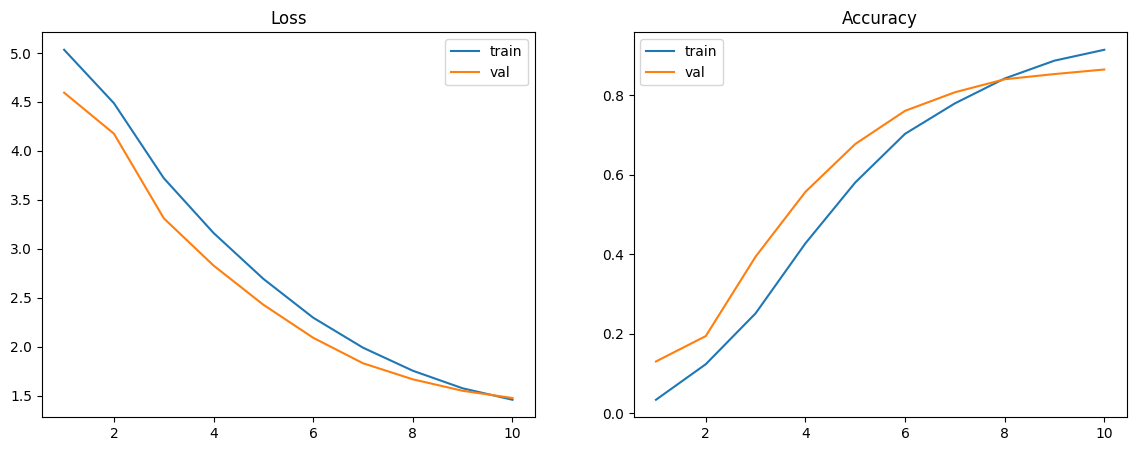

In [89]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df.index + 1, hist_df["train_loss"], label="train")
axes[0].plot(hist_df.index + 1, hist_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df.index + 1, hist_df["train_acc"], label="train")
axes[1].plot(hist_df.index + 1, hist_df["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

In [90]:
ckpt = torch.load(best_path, map_location=device)

model = build_model(len(ckpt["class_names"])).to(device)
model.load_state_dict(ckpt["model_state_dict"])

val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)

print(f"Val loss: {val_loss:.4f}")
print(f"Val acc : {val_acc:.4f}")
print(f"Val F1  : {val_f1:.4f}")

Val loss: 1.4773
Val acc : 0.8642
Val F1  : 0.8600


In [91]:
def predict_loader(model, loader):
    model.eval()
    preds_all = []
    targets_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = logits.argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            targets_all.extend(labels.cpu().numpy())

    return np.array(targets_all), np.array(preds_all)

y_true, y_pred = predict_loader(model, val_loader)

print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0
))

                                                        precision    recall  f1-score   support

                            AM General Hummer SUV 2000       0.88      1.00      0.93         7
                                   Acura RL Sedan 2012       1.00      0.60      0.75         5
                                   Acura TL Sedan 2012       0.71      0.83      0.77         6
                                  Acura TL Type-S 2008       1.00      0.83      0.91         6
                                  Acura TSX Sedan 2012       0.67      0.67      0.67         6
                             Acura Integra Type R 2001       0.71      0.71      0.71         7
                              Acura ZDX Hatchback 2012       0.83      0.83      0.83         6
              Aston Martin V8 Vantage Convertible 2012       0.75      0.86      0.80         7
                    Aston Martin V8 Vantage Coupe 2012       0.83      0.83      0.83         6
                  Aston Martin Virage C

In [92]:
def split_make_model_year(class_name):
    parts = class_name.split()
    if parts and parts[-1].isdigit():
        year = parts[-1]
        make_model = " ".join(parts[:-1])
    else:
        year = ""
        make_model = class_name
    return make_model, year

In [93]:
def predict_image(image_path, topk=3):
    image = Image.open(image_path).convert("RGB")
    x = val_tfms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        vals, idxs = torch.topk(probs, topk)

    results = []
    for p, i in zip(vals.cpu().numpy(), idxs.cpu().numpy()):
        cls = class_names[int(i)]
        make_model, year = split_make_model_year(cls)
        results.append({
            "class": cls,
            "make_model": make_model,
            "year": year,
            "probability": float(p)
        })
    return results

In [94]:
def predict_folder(input_dir, output_csv="/kaggle/working/predictions.csv"):
    input_dir = Path(input_dir)
    rows = []

    for img_path in sorted(input_dir.iterdir()):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".webp"]:
            continue

        pred = predict_image(str(img_path), topk=1)[0]
        rows.append({
            "image": img_path.name,
            "prediction": pred["class"],
            "make_model": pred["make_model"],
            "year": pred["year"],
            "probability": pred["probability"]
        })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(output_csv, index=False)
    return out_df

In [95]:
test_set = CarsDataset(
    TEST_IMG_ROOT,
    test_df,
    transform=val_tfms,
    return_label=("label" in test_df.columns)
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

if "label" in test_df.columns:
    test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion)
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test acc : {test_acc:.4f}")
    print(f"Test F1  : {test_f1:.4f}")
else:
    print("Test split is unlabeled in this dataset copy. Use it only for inference.")

Test split is unlabeled in this dataset copy. Use it only for inference.


In [96]:
label_map_path = "/kaggle/working/class_names.json"
pd.Series(class_names).to_json(label_map_path, orient="values")
print("Saved:", label_map_path)

Saved: /kaggle/working/class_names.json


In [97]:
def infer_loader(model, loader):
    model.eval()
    all_pred_ids = []
    all_pred_probs = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch

            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)

            all_pred_ids.extend(preds.cpu().numpy().tolist())
            all_pred_probs.extend(confs.cpu().numpy().tolist())

    return all_pred_ids, all_pred_probs

In [98]:
pred_ids, pred_probs = infer_loader(model, test_loader)

print("Num predictions:", len(pred_ids))
print("Num test rows:", len(test_df))

Num predictions: 8041
Num test rows: 8041


In [99]:
rows = []
test_df_reset = test_df.reset_index(drop=True)

for i in range(len(test_df_reset)):
    pred_id = int(pred_ids[i])
    prob = float(pred_probs[i])
    class_name = class_names[pred_id]
    make_model, year = split_make_model_year(class_name)

    rows.append({
        "image": test_df_reset.loc[i, "fname"],
        "prediction_id": pred_id,
        "prediction": class_name,
        "make_model": make_model,
        "year": year,
        "probability": prob
    })

preds_df = pd.DataFrame(rows)
preds_df.head()

,image,prediction_id,prediction,make_model,year,probability
0,00001.jpg,180,Suzuki Aerio Sedan 2007,Suzuki Aerio Sedan,2007,0.681761
1,00002.jpg,102,Ferrari 458 Italia Convertible 2012,Ferrari 458 Italia Convertible,2012,0.670132
2,00003.jpg,144,Jeep Patriot SUV 2012,Jeep Patriot SUV,2012,0.937754
3,00004.jpg,186,Toyota Camry Sedan 2012,Toyota Camry Sedan,2012,0.906657
4,00005.jpg,184,Tesla Model S Sedan 2012,Tesla Model S Sedan,2012,0.587743


In [100]:
output_csv = "/kaggle/working/twincar_test_predictions.csv"
preds_df.to_csv(output_csv, index=False)
print("Saved to:", output_csv)

Saved to: /kaggle/working/twincar_test_predictions.csv


In [101]:
simple_df = preds_df[["image", "prediction", "make_model", "year", "probability"]]
simple_output_csv = "/kaggle/working/twincar_test_predictions_simple.csv"
simple_df.to_csv(simple_output_csv, index=False)
print("Saved to:", simple_output_csv)

Saved to: /kaggle/working/twincar_test_predictions_simple.csv


In [102]:
sample_img = os.path.join(TEST_IMG_ROOT, test_df.iloc[0]["fname"])
print(predict_image(sample_img, topk=3))

[{'class': 'Suzuki Aerio Sedan 2007', 'make_model': 'Suzuki Aerio Sedan', 'year': '2007', 'probability': 0.6817610859870911}, {'class': 'Ford Focus Sedan 2007', 'make_model': 'Ford Focus Sedan', 'year': '2007', 'probability': 0.09140785038471222}, {'class': 'Toyota Corolla Sedan 2012', 'make_model': 'Toyota Corolla Sedan', 'year': '2012', 'probability': 0.018251115456223488}]


In [103]:
for i in range(3):
    img_path = os.path.join(TEST_IMG_ROOT, test_df.iloc[i]["fname"])
    preds = predict_image(img_path, topk=3)
    print("Image:", test_df.iloc[i]["fname"])
    for p in preds:
        print(p)
    print("-" * 50)

Image: 00001.jpg
{'class': 'Suzuki Aerio Sedan 2007', 'make_model': 'Suzuki Aerio Sedan', 'year': '2007', 'probability': 0.6817610859870911}
{'class': 'Ford Focus Sedan 2007', 'make_model': 'Ford Focus Sedan', 'year': '2007', 'probability': 0.09140785038471222}
{'class': 'Toyota Corolla Sedan 2012', 'make_model': 'Toyota Corolla Sedan', 'year': '2012', 'probability': 0.018251115456223488}
--------------------------------------------------
Image: 00002.jpg
{'class': 'Ferrari 458 Italia Convertible 2012', 'make_model': 'Ferrari 458 Italia Convertible', 'year': '2012', 'probability': 0.6701314449310303}
{'class': 'Ferrari 458 Italia Coupe 2012', 'make_model': 'Ferrari 458 Italia Coupe', 'year': '2012', 'probability': 0.09278768301010132}
{'class': 'Ferrari California Convertible 2012', 'make_model': 'Ferrari California Convertible', 'year': '2012', 'probability': 0.09187328815460205}
--------------------------------------------------
Image: 00003.jpg
{'class': 'Jeep Patriot SUV 2012', 'ma